# What's in your documents?

**Module 2 — Lesson 1**

Before parsing, investigate the extracted text files to understand their structure. This notebook helps you identify:

1. **Boilerplate** -- government headers and footers
2. **Email headers** -- From, Sent, To, Cc, Subject
3. **Body text** -- the email content
4. **Embedded chains** -- forwarded and replied-to messages
5. **OCR noise** -- character-level errors from scanned documents
6. **Redacted content** -- withheld names and details

In [152]:
%pip install matplotlib -q 

Note: you may need to restart the kernel to use updated packages.


## 1. Load the Extracted Text Files

In [4]:
import re
from pathlib import Path
from collections import Counter

In [5]:
TXT_DIR = Path("data/extracted_text")

txt_files = sorted(TXT_DIR.glob("*.txt"))

# Load all files into memory once -- small enough (~50 MB) to keep in a dict.
# Subsequent cells use corpus[doc_id] instead of re-reading from disk.
corpus = {f.stem: f.read_text(encoding="utf-8") for f in txt_files}

print(f"Loaded {len(corpus):,} text files into memory")

Loaded 4,911 text files into memory


## 2. Inspect a few files

Read a handful of files and look at the raw text. What patterns do you notice?

In [6]:
for doc_id, text in list(corpus.items())[:3]:
    print(f"=== {f"{doc_id}.txt"} ({len(text):,} chars) ===")
    print(text[:500])
    print()

=== E0000813E.txt (944 chars) ===
CONFIDENTIAL
Enron Corp.
Case No. EC-2002-01038
Doc No. E0000813E
Date: 01/15/2003
ENRON CORP. - PRODUCED PURSUANT TO FERC SUBPOENA.
SUBJECT TO PROTECTIVE ORDER. CONFIDENTIAL TREATMENT REQUESTED.
RELEASE IN PART
From:
Rob Bradley <rob.bradley@enron.com>
Sent:
Tue, 21 Nov 2000 08:34:00 -0800 (PST)
To:
Kenneth Lay <kenneth.lay@enron.com>
Cc:
Alhamd Alkhayat <alhamd.alkhayat@enron.com>
Subject:
Remarks to EES Employees--December 1
[REDACTED] B6
EES employee meeting next Friday, and I put together t

=== E0000D1D0.txt (2,841 chars) ===
CONFIDENTIAL
Enron Corp.
Case No. EC-2002-01038
Doc No. E0000D1D0
Date: 01/15/2003
ENRON CORP. - PRODUCED PURSUANT TO FERC SUBPOENA.
SUBJECT TO PROTECTIVE ORDER. CONFIDENTIAL TREATMENT REQUESTED.
CONFIDENTIAL - SUBJECT TO PROTECTIVE ORDER
From:
EDIS Email Service <edismail@incident.com>
Sent:
Fri, 5 Apr 2002 00:07:00 -0800 (PST)
To:
Motley, Matt <matt.motley@enron.com>
Subject:
[EDIS]  EQ 4 2 SAN BERNARDINO COUNTY [News: Sta

## 3. Identify boilerplate

Government documents have classification markings, case numbers, and processing stamps. These appear at the top and bottom of every page -- they're not part of the email.

Some files were scanned at lower quality, so OCR variants of these patterns exist too (`Bate:` for `Date:`, `Enrom` for `Enron`, `COMPIBENTTAT` for `CONFIDENTIAL`). The patterns below catch both clean and OCR-damaged versions.

In [7]:
BOILERPLATE_PATTERNS = [
    r"^'?CONFIDENTIAL",
    r"^'?CONF\s?IBENT",       # OCR variant of CONFIDENTIAL
    r"^'?COMPIBENT",          # OCR variant of CONFIDENTIAL
    r"^'?UNCLASSIFIED",
    r"^Enro[nm] Corp",        # catches Enron and OCR variant Enrom
    r"^Prima Corp",           # OCR variant of Enron Corp
    r"^Case [NW]o[\.:,]",    # catches Case No. and OCR variant Case Wo.
    r"^Doc No\.",
    r"^Doe No",
    r"^Boo No\.",             # OCR variant of Doc No.
    r"^Boor No\.",            # OCR variant of Doc No.
    r"^Gao No\.",             # OCR variant of Doc No.
    r"^Date:\s*\d{2}/\d{2}/\d{4}$",
    r"^Bate:",                # OCR variant of Date:
    r"^Bane:",                # OCR variant of Date:
    r"^Daze:",                # OCR variant of Date:
    r"^Dare:",                # OCR variant of Date:
    r"^ENRON COR[PE]",        # catches CORP and OCR variant CORE
    r"^SUBJECT [TI][OG]",     # catches TO and OCR variant IG/TO
    r"^RELEASE IN",
    r"^ENRON-\d+",
]

# Count how many files contain each pattern
pattern_counts = Counter()

for doc_id, text in corpus.items():
    for pattern in BOILERPLATE_PATTERNS:
        if re.search(pattern, text, re.MULTILINE):
            pattern_counts[pattern] += 1

print("Boilerplate patterns found across corpus:")
for pattern, count in pattern_counts.most_common():
    pct = count / len(txt_files) * 100
    print(f"  {pattern:<35} {count:>5,}  ({pct:.0f}%)")

Boilerplate patterns found across corpus:
  ^'?CONFIDENTIAL                     4,897  (100%)
  ^ENRON-\d+                          4,679  (95%)
  ^SUBJECT [TI][OG]                   4,102  (84%)
  ^Case [NW]o[\.:,]                   4,100  (83%)
  ^ENRON COR[PE]                      4,091  (83%)
  ^Enro[nm] Corp                      4,090  (83%)
  ^Doc No\.                           4,037  (82%)
  ^RELEASE IN                         3,506  (71%)
  ^Date:\s*\d{2}/\d{2}/\d{4}$         3,027  (62%)
  ^Bate:                                127  (3%)
  ^Dare:                                 47  (1%)
  ^Boo No\.                              44  (1%)
  ^Prima Corp                            18  (0%)
  ^Bane:                                 17  (0%)
  ^'?COMPIBENT                           13  (0%)
  ^Gao No\.                              11  (0%)
  ^'?CONF\s?IBENT                         2  (0%)


The regex patterns used here are naive -- in reality you will require much more robust patterns. You'll learn how to create those patterns later. 

## 3b. Finding metadata elsewhere

Not all metadata lives in the document text. PDF files have their own metadata fields -- title, author, creation date -- that may contain useful information.

In real document dumps, PDF metadata often includes the OCR software used, the scan date, and sometimes the document ID. Our synthetic PDFs have minimal metadata, but it's always worth checking.


In [8]:
import pymupdf

PDF_DIR = Path("enron_pdfs")
sample_pdfs = sorted(PDF_DIR.glob("*.pdf"))[:5]

for pdf_path in sample_pdfs:
    doc = pymupdf.open(pdf_path)
    meta = doc.metadata
    doc.close()
    
    print(f"{pdf_path.name}")
    # The filename itself is a document identifier
    print(f"  doc_id (from filename): {pdf_path.stem}")
    # Show any non-empty metadata fields
    for key in ['title', 'author', 'subject', 'creator', 'producer', 'creationDate']:
        val = meta.get(key, '')
        if val:
            print(f"  {key}: {val}")
    print()


E0000813E.pdf
  doc_id (from filename): E0000813E
  title: untitled
  author: anonymous
  subject: unspecified
  creator: anonymous
  producer: ReportLab PDF Library - (opensource)
  creationDate: D:20260329141454+01'00'

E0000D1D0.pdf
  doc_id (from filename): E0000D1D0
  title: untitled
  author: anonymous
  subject: unspecified
  creator: anonymous
  producer: ReportLab PDF Library - (opensource)
  creationDate: D:20260329141457+01'00'

E000B745B.pdf
  doc_id (from filename): E000B745B
  title: untitled
  author: anonymous
  subject: unspecified
  creator: anonymous
  producer: ReportLab PDF Library - (opensource)
  creationDate: D:20260329141452+01'00'

E00292463.pdf
  doc_id (from filename): E00292463
  producer: Tesseract 5.5.2
  creationDate: D:20260329143703+01'00'

E0033CF3B.pdf
  doc_id (from filename): E0033CF3B



## 4. Header patterns

After stripping boilerplate, the email headers begin. Each email has a `From:` label followed by the sender, then `Sent:`, `To:`, optionally `Cc:`, and `Subject:`. Labels appear on their own line with the value on the following line(s) — long recipient lists wrap across multiple lines.

Not every email has all fields. The cell below extracts the field combination from each file and counts how many recipients each To and Cc field contains.


In [9]:
def strip_boilerplate(text):
    """Remove known boilerplate lines."""
    lines = text.split("\n")
    return "\n".join(
        l for l in lines
        if not any(re.match(p, l.strip()) for p in BOILERPLATE_PATTERNS)
    )


LABEL_RE = re.compile(r'^(From|Sent|To|Cc|Bcc|Subject)\s*:', re.IGNORECASE)


def extract_header_fields(text):
    """Extract primary header fields as a dict of label -> raw value."""
    lines = text.split("\n")
    fields = {}
    current = None
    
    for line in lines:
        m = LABEL_RE.match(line.strip())
        if m:
            current = m.group(1).capitalize()
            rest = line.strip()[m.end():].strip()
            fields[current] = rest
            if current == 'Subject':
                break
        elif current and current != 'Subject':
            fields[current] += ' ' + line.strip()
    
    return fields if 'From' in fields else None


def count_values(val, field):
    """Count how many discrete values a field contains."""
    val = val.strip()
    if not val:
        return 0
    if field in ('From', 'Sent', 'Subject'):
        return 1
    # To/Cc: count by <email> brackets or comma-separated names
    emails = re.findall(r'<[^>]+>', val)
    if emails:
        return len(emails)
    return len([n for n in val.split(',') if n.strip()])


# Analyse every file
from collections import defaultdict

combo_counts = Counter()
value_counts = defaultdict(list)
no_header = 0

for doc_id, text in corpus.items():
    fields = extract_header_fields(text)
    if fields is None:
        no_header += 1
        continue
    
    combo_counts[', '.join(fields.keys())] += 1
    
    for label in ['From', 'Sent', 'To', 'Cc', 'Bcc', 'Subject']:
        if label in fields:
            value_counts[label].append(count_values(fields[label], label))

print("Field combinations:")
for combo, count in combo_counts.most_common():
    pct = count / len(txt_files) * 100
    print(f"  {combo:45s} {count:,} ({pct:.1f}%)")
if no_header:
    print(f"  {'(no From: found)':45s} {no_header:,} ({no_header/len(txt_files)*100:.1f}%)")

print("\nValues per field:")
print(f"  {'Field':10s} {'empty':>6s} {'1':>6s} {'2-3':>6s} {'4-10':>6s} {'10+':>6s}")
for label in ['From', 'Sent', 'To', 'Cc', 'Bcc', 'Subject']:
    if label not in value_counts:
        continue
    counts = value_counts[label]
    empty = sum(1 for c in counts if c == 0)
    one = sum(1 for c in counts if c == 1)
    two_three = sum(1 for c in counts if 2 <= c <= 3)
    four_ten = sum(1 for c in counts if 4 <= c <= 10)
    ten_plus = sum(1 for c in counts if c > 10)
    print(f"  {label:10s} {empty:>6,} {one:>6,} {two_three:>6,} {four_ten:>6,} {ten_plus:>6,}")


Field combinations:
  From, Sent, To, Subject                       4,371 (89.0%)
  From, Sent, To, Cc, Subject                   536 (10.9%)
  From, Sent, Subject                           4 (0.1%)

Values per field:
  Field       empty      1    2-3   4-10    10+
  From            0  4,911      0      0      0
  Sent            0  4,911      0      0      0
  To             88  3,067    677    576    499
  Cc              0    191    165    120     60
  Subject     4,911      0      0      0      0


About 72% follow the From/Sent/To/Subject pattern. About 28% also have a Cc field. A handful are missing Subject or To — these are edge cases the parser will need to handle.

The values-per-field table shows that To fields range from empty (no recipients) to 10+ recipients, while From, Sent, and Subject are always single values. This tells you where the parsing complexity lives: splitting multi-recipient To and Cc fields into individual names and email addresses.


## 5. What fields are present?

Not every email has all header fields. Let's check which fields appear most often.

Header field frequency:
  From       4,911 (100.0%)
  Sent       4,910 (100.0%)
  To         4,908 (99.9%)
  Cc         1,384 (28.2%)
  Bcc        2 (0.0%)
  Subject    4,877 (99.3%)


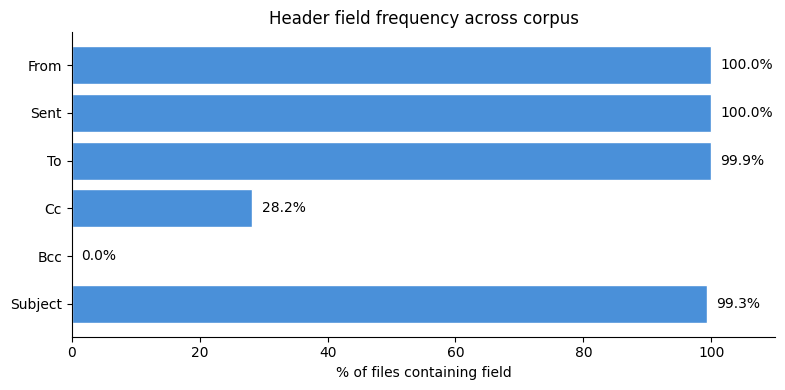


Saved to field_frequency.png


In [10]:
import matplotlib.pyplot as plt

HEADER_LABELS = ["From", "Sent", "To", "Cc", "Bcc", "Subject"]
field_counts = Counter()

for doc_id, text in corpus.items():
    for label in HEADER_LABELS:
        if re.search(rf"^{label}:\s", text, re.MULTILINE | re.IGNORECASE):
            field_counts[label] += 1
        elif re.search(rf"^{label}:\s*$", text, re.MULTILINE | re.IGNORECASE):
            field_counts[label] += 1

total = len(txt_files)
counts = [field_counts.get(label, 0) for label in HEADER_LABELS]
pcts = [c / total * 100 for c in counts]

# Print table
print("Header field frequency:")
for label, count, pct in zip(HEADER_LABELS, counts, pcts):
    print(f"  {label:10s} {count:,} ({pct:.1f}%)")

# Bar chart
fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(HEADER_LABELS[::-1], [pcts[i] for i in range(len(pcts)-1, -1, -1)],
               color="#4a90d9", edgecolor="white")
ax.set_xlim(0, 110)
ax.set_xlabel("% of files containing field")
ax.set_title("Header field frequency across corpus")

for bar, pct in zip(bars, reversed(pcts)):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2,
            f"{pct:.1f}%", va="center", fontsize=10)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.savefig("field_frequency.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nSaved to field_frequency.png")

## 6. Body text

Everything after the headers and before any chain marker is the body -- the unstructured content of the email. For a metadata graph, you may only need the headers. But for an entity graph, the body is where the value is.

In [11]:
CHAIN_PATTERN = re.compile(
    r"-----\s*(Original Message|Forwarded by)\s*-----", re.IGNORECASE
)

# Signals the start of a repeated boilerplate block (standalone on a line)
BOILERPLATE_RESTART = re.compile(
    r"(?i)^'?(confidential|unclassified|enron)$"
)

# Broader patterns for trimming trailing junk after the body
TRAILING_JUNK = BOILERPLATE_PATTERNS + [
    r"(?i)^enron",     # OCR variants like "ENRON. CORP."
    r"^Corp",          # OCR-split "Enron Corp"
    r"^[.:\s;,¢]+$",  # pure punctuation / OCR artifacts
    r"^\d+$",          # bare numbers
]


def extract_body(text):
    """Extract body text between the Subject field and the first chain marker."""
    cleaned = strip_boilerplate(text)
    lines = cleaned.split("\n")

    # Find the first Subject line (last standard header field)
    body_start = None
    for i, line in enumerate(lines):
        s = line.strip()
        if re.match(r"Subject:\s+\S", s, re.IGNORECASE):
            # Same-line: "Subject: Re: thing" — body starts next line
            body_start = i + 1
            break
        elif re.match(r"Subject:\s*$", s, re.IGNORECASE):
            # Alternating: "Subject:" alone — skip the value line
            body_start = i + 2
            break

    if body_start is None or body_start >= len(lines):
        return ""

    # Find end: chain marker or boilerplate restart
    body_end = len(lines)
    for i in range(body_start, len(lines)):
        s = lines[i].strip()
        if CHAIN_PATTERN.search(s):
            body_end = i
            break
        if BOILERPLATE_RESTART.match(s):
            body_end = i
            break

    # Trim trailing junk (OCR artifacts, empty lines)
    body_lines = lines[body_start:body_end]
    while body_lines:
        s = body_lines[-1].strip()
        if not s or any(re.match(p, s) for p in TRAILING_JUNK):
            body_lines.pop()
        else:
            break

    return "\n".join(body_lines).strip()


# Show body text for a few emails
for doc_id, text in list(corpus.items())[:5]:
    body = extract_body(text)
    print(f"=== {f"{doc_id}.txt"} ({len(body):,} chars) ===")
    print(body[:200] if body else "(empty)")
    print()

=== E0000813E.txt (297 chars) ===
[REDACTED] B6
EES employee meeting next Friday, and I put together the attached as a
potential framework.  It provides an Enron problem list of 1985/86 versus
today and a brief look at our different v

=== E0000D1D0.txt (1,736 chars) ===
PRELIMINARY EVENT REPORT
Southern California Seismic Network (TriNet) operated by Caltech and USGS
Version 1: This report supersedes any earlier reports about this event.
This is a computer generated 

=== E000B745B.txt (1,575 chars) ===
Approved.
Christine Stokes
05/31/2000 08:35 AM
To: Lorraine Lindberg, Steven Harris/ET&S/Enron@ENRON, Drew
Fossum/ET&S/Enron@ENRON, Mary Kay Miller/ET&S/Enron@ENRON, Glen
Hass/ET&S/Enron@ENRON, Mary D

=== E00292463.txt (759 chars) ===
On December 26, SoCalEd filed a Petition for a Writ of Mandamus against FERC 
regarding FERC's December 15 order, asking the Court of Appeals for the D.C. 
Circuit to direct FERC to establish and orde

=== E0033CF3B.txt (749 chars) ===
4/9/01; HourAhead 

In [12]:
body_lengths = []

for doc_id, text in corpus.items():
    body = extract_body(text)
    body_lengths.append(len(body))

empty = sum(1 for l in body_lengths if l == 0)
short = sum(1 for l in body_lengths if 0 < l <= 50)
medium = sum(1 for l in body_lengths if 50 < l <= 500)
long = sum(1 for l in body_lengths if l > 500)

print("Body length distribution:")
print(f"  Empty (0 chars):      {empty:,}")
print(f"  Short (1-50 chars):   {short:,}")
print(f"  Medium (51-500):      {medium:,}")
print(f"  Long (500+):          {long:,}")

Body length distribution:
  Empty (0 chars):      107
  Short (1-50 chars):   314
  Medium (51-500):      1,836
  Long (500+):          2,654


Bear in mind, many of these emails consist of nested threads. Here, we are naively defining the 'body' as 'anything below the subject line'. 

In the next course (*Entity Extraction for Communication Networks*), you'll work on decomposing these threads and resolving duplicate thread components across the network.

## 7. Embedded chains

Many emails contain forwarded or replied-to messages embedded in the body. These have their own `From:`, `Sent:`, `To:`, `Subject:` blocks.

In [13]:
chain_markers = [
    r"-----Original Message-----",
    r"-----Forwarded by",
    r"----- Forwarded by",
]

chain_count = 0
multi_chain = 0

for doc_id, text in corpus.items():
    markers_found = sum(
        len(re.findall(marker, text)) for marker in chain_markers
    )
    if markers_found > 0:
        chain_count += 1
    if markers_found > 1:
        multi_chain += 1

print(f"Emails with embedded chains:  {chain_count:,} / {len(txt_files):,}")
print(f"Emails with multiple chains:  {multi_chain:,} / {len(txt_files):,}")

Emails with embedded chains:  1,377 / 4,911
Emails with multiple chains:  423 / 4,911


## 8. Redacted content

Some emails contain content that was redacted before release -- names, amounts, or other details replaced with markers like `[REDACTED]`. These aren't just missing data -- they tell you that someone or something was mentioned but withheld.

In [14]:
REDACTION_PATTERNS = [
    r"\[REDACTED\]",
    r"\[redacted\]",
    r"XXXXXXX+",
    r"\[DELETED\]",
    r"\[WITHHELD\]",
]

redacted_files = []

for doc_id, text in corpus.items():
    for pattern in REDACTION_PATTERNS:
        if re.search(pattern, text):
            redacted_files.append(f"{doc_id}.txt")
            break

print(f"Files with redaction markers: {len(redacted_files):,} / {len(txt_files):,}")

if redacted_files:
    print("\nExamples:")
    for name in redacted_files[:3]:
        text = corpus.get(name.replace(".txt", ""), "")
        cleaned = strip_boilerplate(text)
        print(f"\n--- {name} ---")
        print(cleaned[:400])
else:
    print("\nNo explicit redaction markers found in this corpus.")
    print("Check for 'RELEASE IN PART' -- these files had content withheld:")
    part_count = sum(
        1 for p in txt_files
        if "RELEASE IN PART" in corpus.get(p.stem, "")
    )
    print(f"  RELEASE IN PART: {part_count:,} / {len(txt_files):,}")

Files with redaction markers: 710 / 4,911

Examples:

--- E0000813E.txt ---
From:
Rob Bradley <rob.bradley@enron.com>
Sent:
Tue, 21 Nov 2000 08:34:00 -0800 (PST)
To:
Kenneth Lay <kenneth.lay@enron.com>
Cc:
Alhamd Alkhayat <alhamd.alkhayat@enron.com>
Subject:
Remarks to EES Employees--December 1
[REDACTED] B6
EES employee meeting next Friday, and I put together the attached as a
potential framework.  It provides an Enron problem list of 1985/86 versus
today and a brief loo

--- E000B745B.txt ---
From:
Susan Scott <susan.scott@enron.com>
Sent:
Wed, 31 May 2000 02:24:00 -0700 (PDT)
To:
[REDACTED] B6
Cc:
Drew Fossum
Subject:
Re: Transwestern CAF Request
Approved.
Christine Stokes
05/31/2000 08:35 AM
To: Lorraine Lindberg, Steven Harris/ET&S/Enron@ENRON, Drew
Fossum/ET&S/Enron@ENRON, Mary Kay Miller/ET&S/Enron@ENRON, Glen
Hass/ET&S/Enron@ENRON, Mary Darveaux/ET&S/Enron@ENRON, Bill
Cordes/ET&S

--- E0033CF3B.txt ---
Enron
Corp.
Case
No.
EC-2002-01038
Doc
No.
E0O033CF3B
Date:
01/15/2003
ENRON

Redactions appear in headers (recipient names, subjects) and body text alike. For a communication network, they're worth tracking as entities -- a `[REDACTED]` marker tells you that a relationship existed even though the details were withheld. We'll handle these during parsing.

Note: In the real world, Redactions often contain a code that can tell you _why_ something was redacted. This, in itself, is useful information.

## 9. OCR noise

About 3% of files have noticeable OCR errors from lower-quality scans. These are character-level substitutions -- not random garbage, but predictable confusions where visually similar characters get swapped.

In [16]:
# OCR artifacts found in the dataset
ocr_indicators = [
    (r"Bate:", "Bate: (Date:)"),
    (r"Bane:", "Bane: (Date:)"),
    (r"Daze:", "Daze: (Date:)"),
    (r"Dare:", "Dare: (Date:)"),
    (r"ENRON CORE\.", "ENRON CORE. (ENRON CORP.)"),
    (r"EROTECTIVE", "EROTECTIVE (PROTECTIVE)"),
    (r"Subject :", "Subject : (space before colon)"),
    (r"Boo No\.", "Boo No. (Doc No.)"),
    (r"COMPIBENT", "COMPIBENT (CONFIDENTIAL)"),
    (r"Prima Corp", "Prima Corp (Enron Corp)"),
    (r"Toa:", "Toa: (To:)"),
]

from collections import Counter
ocr_counts = Counter()
ocr_noisy_files = set()

for doc_id, text in corpus.items():
    for pattern, label in ocr_indicators:
        if re.search(pattern, text):
            ocr_counts[label] += 1
            ocr_noisy_files.add(f"{doc_id}.txt")

print(f"Files with OCR artifacts: {len(ocr_noisy_files):,} / {len(txt_files):,}")
print()
print("OCR variant frequency:")
for variant, count in ocr_counts.most_common():
    print(f"  {variant}: {count}")

# Show a few examples
print(f"\nSample OCR-noisy file:")
if ocr_noisy_files:
    sample = sorted(ocr_noisy_files)[0]
    text = corpus.get(sample.replace(".txt", ""), "")
    print(f"  {sample}")
    print(text[:300])

Files with OCR artifacts: 193 / 4,911

OCR variant frequency:
  Bate: (Date:): 127
  ENRON CORE. (ENRON CORP.): 108
  EROTECTIVE (PROTECTIVE): 99
  Subject : (space before colon): 81
  Dare: (Date:): 47
  Boo No. (Doc No.): 44
  Prima Corp (Enron Corp): 18
  Bane: (Date:): 17
  COMPIBENT (CONFIDENTIAL): 13

Sample OCR-noisy file:
  E030DC3E4.txt
CONFIDENTIAL 
Enron Corp. 
Case No. EC-2002-C01038 
Doo No. EG3coc3ea 
Bate: G1/15/2003 
ENRON CORE. - PRODUCED PURSUANT TO FERC SUBPOENA. 
SUBJECT TO EFROTECTIVE ORDER. CONFIDENTIAL TREATMENT REQUESTED. 
RELEASE IN FULL 
From: 
Gus Eghneim <gus.eghneim@enron, 
com> 
Sent: 
Tue, 24 Oct 2000 04:20:00


Again, bear in mind that we have used a naive regex to find specific and known examples. There are likely many more in here of which we are currently unaware.

## 10. Summary

You've now investigated the raw data and understand:

- **Boilerplate** lines that need stripping before parsing (including OCR variants like `Bate:`, `ENRON CORE.`)
- **Header field combinations** — about 72% have From/Sent/To/Subject, about 28% also have Cc, a few are missing fields
- **Multi-recipient fields** — To and Cc can contain many recipients across multiple lines
- **Body text** follows the headers, with variable length
- **Embedded chains** (forwarded/replied messages) appear in 28% of emails
- **Redactions** (`[REDACTED]`) mark withheld content — worth tracking as entities
- **OCR noise** affects about 3% of files — predictable character substitutions (`Bate:` for `Date:`, `ENRON CORE.` for `ENRON CORP.`)

These observations shape every parsing decision in the lessons ahead.
